In [1]:
# Third-party imports
import tensorflow as tf
import tensorflow_datasets as tfds
from IPython.display import Image, display

I0000 00:00:1773822477.144545   13801 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773822477.197421   13801 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773822478.612646   13801 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Verify TensorFlow version
assert tf.__version__.startswith('2.')
print("GPU disponibili:", tf.config.list_physical_devices('GPU'))
print("Versione TensorFlow:", tf.__version__)

GPU disponibili: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Versione TensorFlow: 2.21.0


In [3]:
# Abilita la crescita dinamica della memoria GPU (usa solo la memoria necessaria)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
# Load the Iris dataset with defined splits for training and testing
(ds_train, ds_test), ds_info = tfds.load(
    'iris',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,  # Load the dataset as (feature, label) pairs
    with_info=True       # Retrieve the metadata of the dataset
)


I0000 00:00:1773822508.298579   13801 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
# Function to preprocess the dataset by one-hot encoding the labels
def preprocess(features, label):
    label = tf.one_hot(label, depth=3)  # 3 classes in the Iris dataset
    return features, label


In [6]:
# Prepare the train and test datasets
train_data = ds_train.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_data = ds_test.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

# Define a simple neural network for classification
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(4,)),  # Input shape is 4 for the four Iris features
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # Softmax for multi-class classification
])

# Compile the model with optimizer, loss function, and metrics
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/home/lucalinux/coding/eu-certif-ai/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,091 (35.51 KB)

 Trainable params: 9,091 (35.51 KB)

 Non-trainable params: 0 (0.00 B)

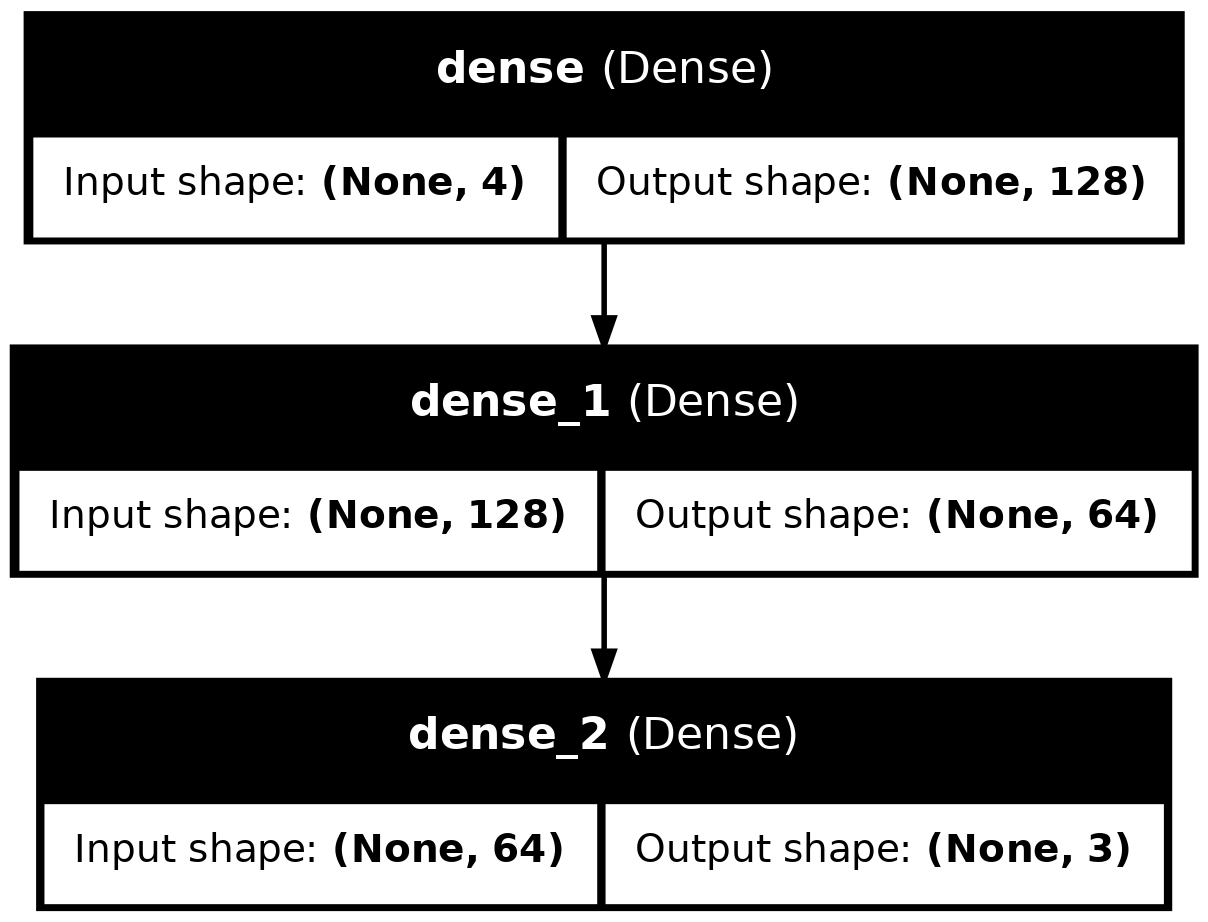

In [7]:
# Visualize the model architecture
print("Model Summary:")
model.summary()

# Create a visual graph of the model
tf.keras.utils.plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the image in the notebook
display(Image('model_architecture.png'))

In [8]:
# Train the model on the training data and validate on the test data
history = model.fit(train_data, epochs=50, validation_data=test_data)

# Evaluate the model's performance on the test dataset
loss, accuracy = model.evaluate(test_data)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")


Epoch 1/50


I0000 00:00:1773822612.812543   15206 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
I0000 00:00:1773822612.817811   14457 service.cc:153] XLA service 0x78b7b8042960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773822612.817852   14457 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773822612.861213   14457 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773822613.049910   14457 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773822613.062567   14457 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1429__.17
I0000 00:00:1773822614.207068   14457 dot_search_space.cc:240] All configs were filtered out because none

1/4 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.3125 - loss: 1.2944

I0000 00:00:1773822616.390538   14457 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1773822616.565806   14456 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1429__.17


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3500 - loss: 1.1529 - val_accuracy: 0.3333 - val_loss: 1.0221
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3500 - loss: 0.9901 - val_accuracy: 0.6333 - val_loss: 0.9205
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6750 - loss: 0.8729 - val_accuracy: 0.6667 - val_loss: 0.8159
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.7721 - val_accuracy: 0.8667 - val_loss: 0.7410
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8333 - loss: 0.6906 - val_accuracy: 0.6333 - val_loss: 0.6784
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7000 - loss: 0.6249 - val_accuracy: 0.6333 - val_loss: 0.6255
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7167 - loss: 0.5691 - val_accuracy: 0.8000 - val_loss: 0.5759
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9000 - loss: 0.5233 - val_accuracy: 0.9000 - val_loss: 0.5374
Epoch 9/50
4/

In [9]:
# Use the model to make predictions on a new sample
sample_data = tf.constant([[5.1, 3.3, 1.7, 0.5]])  # Example measurements of an iris flower

# Make the predictions
predictions = model.predict(sample_data)
predicted_class = tf.argmax(predictions, axis=1).numpy()

print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Predicted class: [0]
